In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# 列名を日本語に変更
df.columns = ["がくの長さ", "がくの幅", "花びらの長さ", "花びらの幅", "品種"]

df.head()

,がくの長さ,がくの幅,花びらの長さ,花びらの幅,品種
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# 問題
x = df.drop("品種", axis=1)
# 答え
y = df["品種"]

x.head()

,がくの長さ,がくの幅,花びらの長さ,花びらの幅
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: 品種, dtype: int64

In [5]:

from sklearn.model_selection import train_test_split

# 訓練用の特徴量、訓練用の目的変数
# テスト用の特徴量、テスト用の目的変数
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)

(120, 4)
(30, 4)


In [6]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

print("学習完了")

学習完了


In [7]:
y_pred = model.predict(x_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [8]:
from sklearn.metrics import accuracy_score

score = accuracy_score(y_test, y_pred)

print(f"{score * 100}%")

100.0%


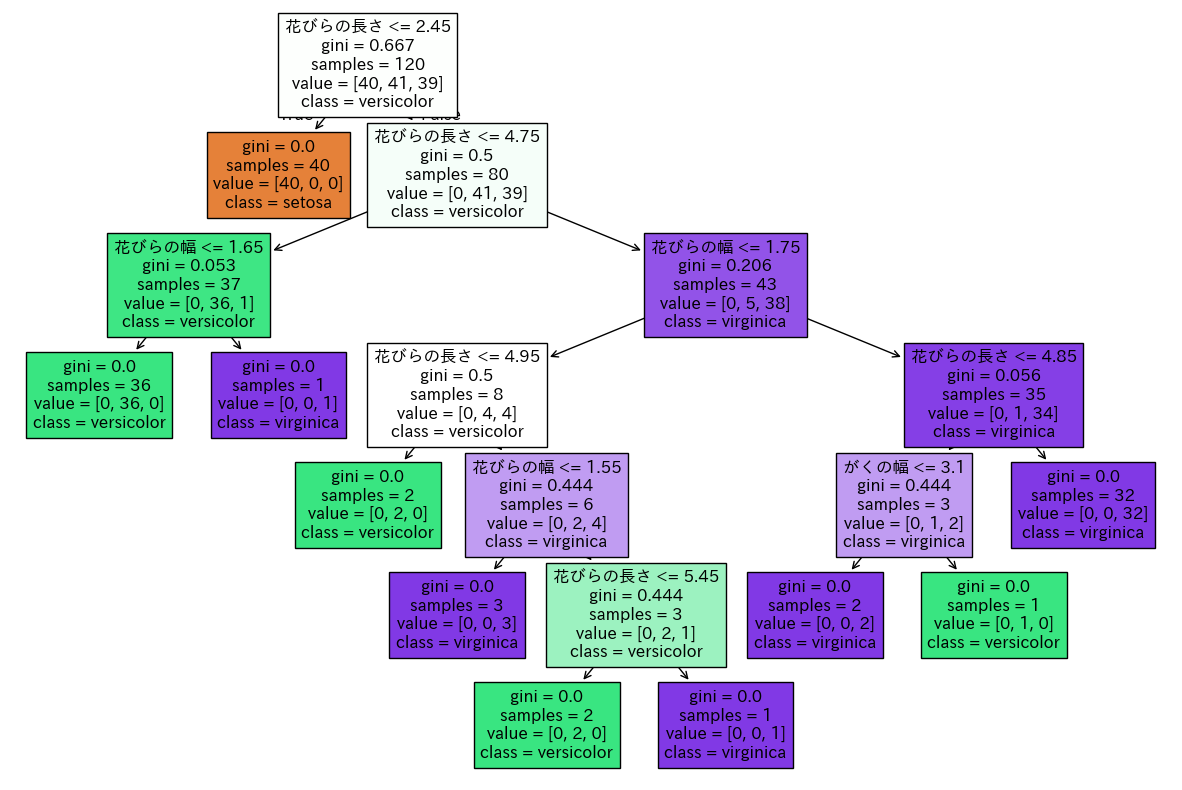

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=iris.target_names,
    filled=True
)

plt.show()

In [13]:
new_flower = pd.DataFrame([[6.0, 3.0, 4.8, 1.8]], columns=x.columns)

prediction = model.predict(new_flower)

print(iris.target_names[prediction[0]])

virginica


In [14]:
test_flower = pd.DataFrame([[5.0, 3.0, 2.0, 0.5]], columns=x.columns)

answer = model.predict(test_flower)
print(iris.target_names[answer][0])

setosa
